# Pipeline 1: Resident Risk Classification
## 1. Business Understanding

**Context:** Tahanan ng Pagmamahal Lighthouse operates multiple safehouses across the region, each housing child residents who have experienced trafficking, abuse, neglect, exploitation, or are at risk of harm. Social workers and case managers carry high caseloads, often managing residents across more than one safehouse location.

**The problem:** Girls falling through the cracks. When caseloads are high and resources are limited, high-risk residents may not receive timely intervention. A resident whose risk level has escalated from Medium to High may wait days or weeks before a case manager notices — time that can be critical for safety and recovery.

**The goal:** Build an early warning system that surfaces residents most likely to be at **High or Critical risk** so that case managers can prioritize outreach, schedule check-ins, and escalate intervention plans proactively.

**What the model does:**
- Takes structured records from seven source tables (resident demographics, health, education, case sessions, home visits, incidents, intervention plans)
- Outputs a binary risk flag: `0 = low/medium risk`, `1 = high/critical risk`
- Also fits an explanatory multinomial logistic regression to understand *which factors* drive elevated risk

**Privacy and ethics notice:**
> These residents are survivors of abuse, trafficking, and exploitation. Model outputs **must never be shown to residents themselves.** This model is a tool for trained case managers only. It is a screening aid — not a replacement for professional judgment. Any flagged resident must be reviewed by a qualified social worker before any action is taken.

## TL;DR

- **Business question:** Which currently-active residents are at highest immediate risk so case managers can intervene before a crisis?
- **Approach:** Predictive classification — Random Forest (winner) vs. Logistic Regression baseline, 5-fold stratified CV on N=61 residents with 6 positives.
- **Headline metric:** CV ROC-AUC **0.87 ± 0.11** — strong on paper; the wide CI reflects the small positive class.
- **Deployed at:** [`/resident-risk-triage`](https://kateri.byuisresearch.com/resident-risk-triage) — ranked list + detail view that compares the model's verdict against the human-assigned label.
- **Key insight:** Incident count, mental health trend, and session concerns rate are the top three drivers — matches case-manager intuition.


## 2. Data Acquisition and Preparation

In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

# Walk up from cwd to find the is455/ml-pipelines directory
ROOT = Path.cwd()
for _ in range(8):
    ml_path = ROOT / 'is455' / 'ml-pipelines'
    if ml_path.exists():
        break
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / 'is455' / 'ml-pipelines'))

from utils.db_loader import get_engine, load_table
engine = get_engine()
print('Engine created successfully.')

Engine created successfully.


In [2]:
# ── Resolve project root and load utilities ───────────────────────────────────
ROOT = Path.cwd()
for _ in range(8):
    if (ROOT / 'is455' / 'ml-pipelines').exists():
        break
    ROOT = ROOT.parent

MLPIPELINES = ROOT / 'is455' / 'ml-pipelines'
sys.path.insert(0, str(MLPIPELINES))

from utils.db_loader import get_engine, load_table
from utils.onnx_exporter import export_to_onnx, verify_onnx

print(f'Project root: {ROOT}')
print(f'ml-pipelines: {MLPIPELINES}')

Project root: /Users/nathanblatter/Desktop/INTEX-II
ml-pipelines: /Users/nathanblatter/Desktop/INTEX-II/is455/ml-pipelines


In [3]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Load all 7 tables
residents             = load_table(engine, 'residents')
health_wellbeing      = load_table(engine, 'health_wellbeing_records')
education             = load_table(engine, 'education_records')
process_recordings    = load_table(engine, 'process_recordings')
home_visitations      = load_table(engine, 'home_visitations')
incident_reports      = load_table(engine, 'incident_reports')
intervention_plans    = load_table(engine, 'intervention_plans')

print(f'residents:           {residents.shape}')
print(f'health_wellbeing:    {health_wellbeing.shape}')
print(f'education:           {education.shape}')
print(f'process_recordings:  {process_recordings.shape}')
print(f'home_visitations:    {home_visitations.shape}')
print(f'incident_reports:    {incident_reports.shape}')
print(f'intervention_plans:  {intervention_plans.shape}')

residents:           (62, 49)
health_wellbeing:    (534, 14)
education:           (534, 10)
process_recordings:  (2817, 15)
home_visitations:    (1338, 14)
incident_reports:    (101, 12)
intervention_plans:  (191, 11)


In [4]:
# Missingness overview
def missingness_summary(df, name):
    miss = df.isnull().mean().sort_values(ascending=False)
    miss = miss[miss > 0]
    if len(miss) == 0:
        print(f'{name}: no missing values')
        return
    print(f'\n{name} — columns with missing values:')
    for col, pct in miss.items():
        print(f'  {col:45s} {pct*100:5.1f}%')

for df, name in [
    (residents, 'residents'),
    (health_wellbeing, 'health_wellbeing'),
    (education, 'education'),
    (process_recordings, 'process_recordings'),
    (home_visitations, 'home_visitations'),
    (incident_reports, 'incident_reports'),
    (intervention_plans, 'intervention_plans'),
]:
    missingness_summary(df, name)


residents — columns with missing values:
  notes_restricted                              100.0%
  pwd_type                                       95.2%
  special_needs_diagnosis                        90.3%
  date_closed                                    51.6%
  date_colb_obtained                             41.9%
  referring_agency_person                        41.9%
  date_colb_registered                           24.2%
  date_case_study_prepared                       21.0%
  assigned_social_worker                          3.2%
  length_of_stay                                  3.2%
  present_age                                     3.2%
  age_upon_admission                              3.2%
  initial_case_assessment                         3.2%
  family_informal_settler                         3.2%
  family_parent_pwd                               3.2%
  family_indigenous                               3.2%
  family_is_4ps                                   3.2%
  has_special_needs    

In [5]:
# Preview key string columns that require parsing
print('Sample age_upon_admission values:')
print(residents['age_upon_admission'].dropna().unique()[:10])
print('\nSample length_of_stay values:')
print(residents['length_of_stay'].dropna().unique()[:10])
print('\ncurrent_risk_level distribution:')
print(residents['current_risk_level'].value_counts())

Sample age_upon_admission values:
<StringArray>
[ '15 Years 9 months',  '15 Years 5 months',  '18 Years 3 months',
 '12 Years 11 months',  '15 Years 4 months', '18 Years 10 months',
   '9 Years 7 months',  '12 Years 6 months',  '15 Years 7 months',
  '18 Years 6 months']
Length: 10, dtype: str

Sample length_of_stay values:
<StringArray>
[ '2 Years 4 months',  '1 Years 9 months',  '1 Years 5 months',
  '0 Years 9 months',  '2 Years 6 months',  '1 Years 8 months',
  '2 Years 0 months',  '1 Years 1 months', '1 Years 10 months',
  '2 Years 9 months']
Length: 10, dtype: str

current_risk_level distribution:
current_risk_level
Low         33
Medium      20
High         5
Critical     1
low          1
Name: count, dtype: int64


## 3. Exploratory Data Analysis

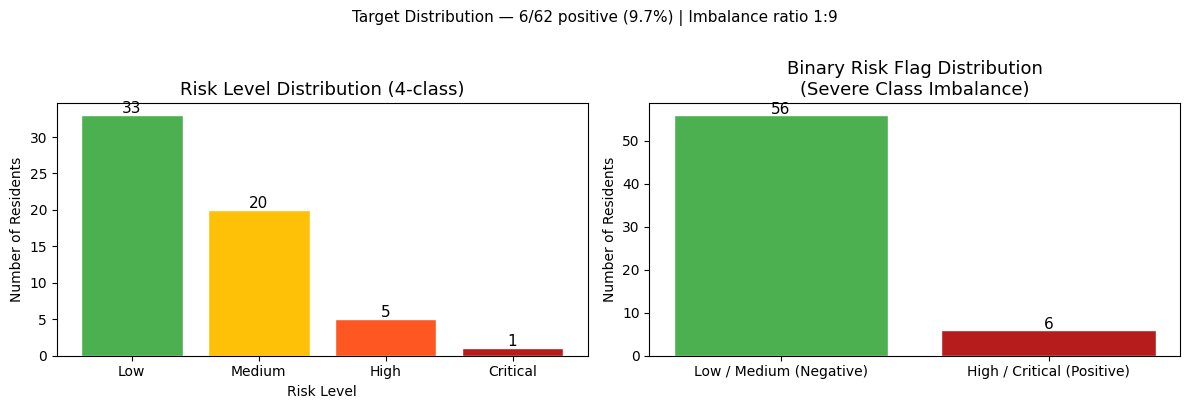


IMPORTANT: Only ~10% of residents are High/Critical.
A naive classifier predicting all-Low would achieve ~90% accuracy — this is WHY accuracy is meaningless here.


In [6]:
# Target class distribution — show imbalance clearly
risk_counts = residents['current_risk_level'].value_counts().reindex(
    ['Low', 'Medium', 'High', 'Critical'], fill_value=0
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 4-class distribution
colors = ['#4CAF50', '#FFC107', '#FF5722', '#B71C1C']
axes[0].bar(risk_counts.index, risk_counts.values, color=colors, edgecolor='white')
for i, (lbl, val) in enumerate(risk_counts.items()):
    axes[0].text(i, val + 0.3, str(val), ha='center', fontsize=11)
axes[0].set_title('Risk Level Distribution (4-class)', fontsize=13)
axes[0].set_xlabel('Risk Level')
axes[0].set_ylabel('Number of Residents')

# Binary (collapsed)
high_risk_flag = residents['current_risk_level'].apply(
    lambda v: 'High / Critical (Positive)' if str(v) in {'High', 'Critical'} else 'Low / Medium (Negative)'
)
binary_counts = high_risk_flag.value_counts()
axes[1].bar(binary_counts.index, binary_counts.values,
            color=['#4CAF50', '#B71C1C'], edgecolor='white')
for i, (lbl, val) in enumerate(binary_counts.items()):
    axes[1].text(i, val + 0.3, str(val), ha='center', fontsize=11)
axes[1].set_title('Binary Risk Flag Distribution\n(Severe Class Imbalance)', fontsize=13)
axes[1].set_ylabel('Number of Residents')

total = len(residents)
n_pos = (high_risk_flag == 'High / Critical (Positive)').sum()
fig.suptitle(
    f'Target Distribution — {n_pos}/{total} positive ({n_pos/total*100:.1f}%) | '
    f'Imbalance ratio 1:{(total-n_pos)//max(n_pos,1)}',
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.show()
print('\nIMPORTANT: Only ~10% of residents are High/Critical.')
print('A naive classifier predicting all-Low would achieve ~90% accuracy — this is WHY accuracy is meaningless here.')

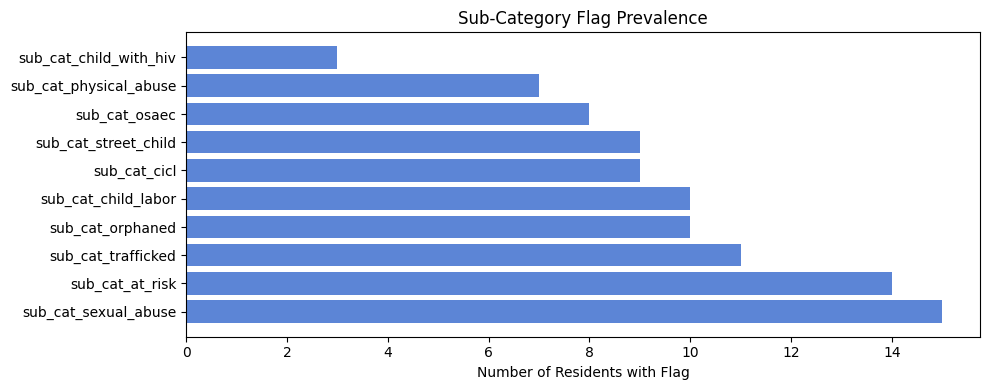

In [7]:
# Sub-category flag frequency
sub_cat_cols = [
    'sub_cat_orphaned', 'sub_cat_trafficked', 'sub_cat_child_labor',
    'sub_cat_physical_abuse', 'sub_cat_sexual_abuse', 'sub_cat_osaec',
    'sub_cat_cicl', 'sub_cat_at_risk', 'sub_cat_street_child', 'sub_cat_child_with_hiv'
]
existing_sub = [c for c in sub_cat_cols if c in residents.columns]
sub_df = residents[existing_sub].copy()
for col in existing_sub:
    sub_df[col] = sub_df[col].map({True: 1, False: 0, 'True': 1, 'False': 0}).fillna(0)

sub_counts = sub_df.sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(sub_counts.index, sub_counts.values, color='#5C85D6')
ax.set_xlabel('Number of Residents with Flag')
ax.set_title('Sub-Category Flag Prevalence')
plt.tight_layout()
plt.show()

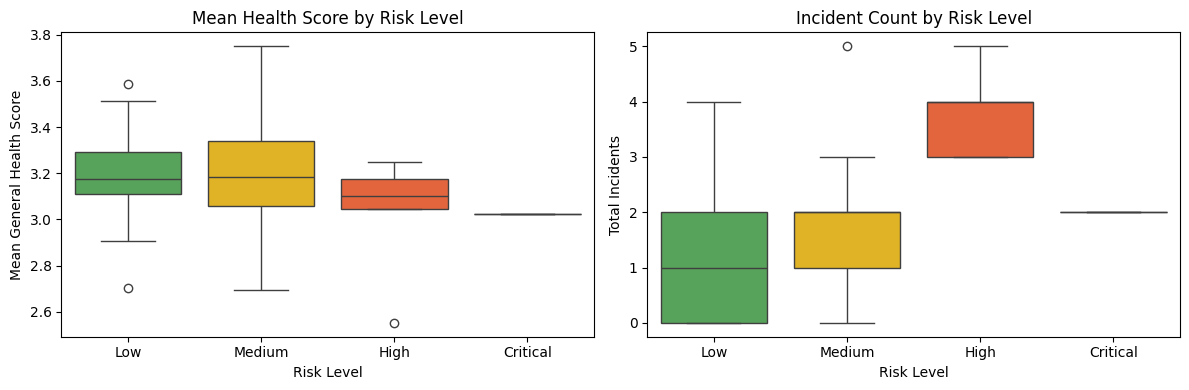

In [8]:
# Health scores by risk level
hw = health_wellbeing.copy()
hw['general_health_score'] = pd.to_numeric(hw['general_health_score'], errors='coerce')
hw_mean = hw.groupby('resident_id')['general_health_score'].mean().reset_index()
hw_mean.columns = ['resident_id', 'mean_health_score']

plot_df = residents[['resident_id', 'current_risk_level']].merge(hw_mean, on='resident_id', how='left')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

order = ['Low', 'Medium', 'High', 'Critical']
order_present = [l for l in order if l in plot_df['current_risk_level'].values]
sns.boxplot(
    data=plot_df, x='current_risk_level', y='mean_health_score',
    order=order_present, palette=['#4CAF50', '#FFC107', '#FF5722', '#B71C1C'],
    ax=axes[0]
)
axes[0].set_title('Mean Health Score by Risk Level')
axes[0].set_xlabel('Risk Level')
axes[0].set_ylabel('Mean General Health Score')

# Incident count by risk level
inc_count = incident_reports.groupby('resident_id').size().reset_index(name='incident_count')
plot_df2 = residents[['resident_id', 'current_risk_level']].merge(inc_count, on='resident_id', how='left')
plot_df2['incident_count'] = plot_df2['incident_count'].fillna(0)
sns.boxplot(
    data=plot_df2, x='current_risk_level', y='incident_count',
    order=order_present, palette=['#4CAF50', '#FFC107', '#FF5722', '#B71C1C'],
    ax=axes[1]
)
axes[1].set_title('Incident Count by Risk Level')
axes[1].set_xlabel('Risk Level')
axes[1].set_ylabel('Total Incidents')

plt.tight_layout()
plt.show()

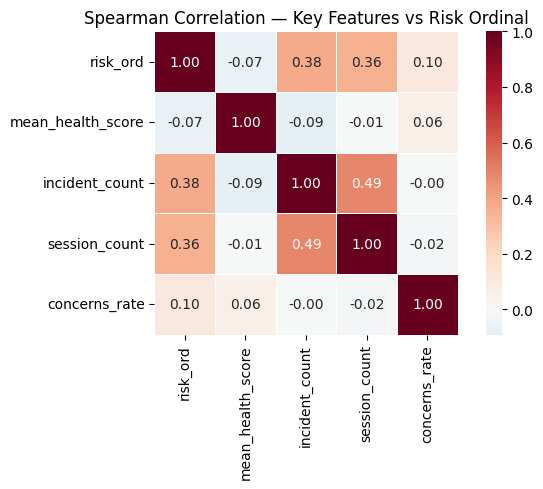

In [9]:
# Correlation heatmap of key numeric aggregates vs risk ordinal
from scipy.stats import spearmanr

risk_ordinal_map = {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3}
residents['risk_ord'] = residents['current_risk_level'].map(risk_ordinal_map)

inc_count = incident_reports.groupby('resident_id').size().reset_index(name='incident_count')
pr_concern = process_recordings.copy()
pr_concern['cf'] = pr_concern['concerns_flagged'].map({True: 1, False: 0, 'True': 1, 'False': 0}).fillna(0)
pr_agg = pr_concern.groupby('resident_id').agg(session_count=('recording_id','count'), concerns_rate=('cf','mean')).reset_index()

corr_base = residents[['resident_id','risk_ord']].copy()
corr_base = corr_base.merge(hw_mean, on='resident_id', how='left')
corr_base = corr_base.merge(inc_count, on='resident_id', how='left')
corr_base = corr_base.merge(pr_agg, on='resident_id', how='left')
corr_base = corr_base.fillna(0)

corr_cols = ['risk_ord', 'mean_health_score', 'incident_count', 'session_count', 'concerns_rate']
corr_cols = [c for c in corr_cols if c in corr_base.columns]
corr_matrix = corr_base[corr_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Spearman Correlation — Key Features vs Risk Ordinal')
plt.tight_layout()
plt.show()

## 4. Feature Engineering

All aggregation is performed in pandas **before** the sklearn pipeline. This is important because:
1. String-to-numeric parsing (e.g., `'15 Years 9 months'`) cannot be safely embedded in ONNX-exportable sklearn transformers.
2. Aggregated features (mean health score, incident count) represent each resident as a single row, which is the unit of prediction.
3. Keeping feature engineering in pandas makes it auditable and reproducible without requiring custom sklearn transformers.

In [10]:
# -- String parsers --

def parse_years_months(s) -> float:
    """'15 Years 9 months' -> 15.75 (years as float)"""
    if pd.isna(s) or str(s).strip() == '':
        return 0.0
    s = str(s)
    years  = int(m.group(1)) if (m := re.search(r'(\d+)\s*[Yy]ear', s)) else 0
    months = int(m.group(1)) if (m := re.search(r'(\d+)\s*[Mm]onth', s)) else 0
    return float(years) + float(months) / 12.0

def parse_los_days(s) -> float:
    """Parse length_of_stay into days. Supports '45 Days', '1 Year 3 months', bare numbers."""
    if pd.isna(s) or str(s).strip() == '':
        return 0.0
    s = str(s)
    if (m := re.search(r'(\d+)\s*[Dd]ay', s)):
        return float(m.group(1))
    years  = int(m.group(1)) if (m := re.search(r'(\d+)\s*[Yy]ear', s)) else 0
    months = int(m.group(1)) if (m := re.search(r'(\d+)\s*[Mm]onth', s)) else 0
    if years or months:
        return float(years * 365 + months * 30)
    if (m := re.search(r'^\s*(\d+(?:\.\d+)?)\s*$', s)):
        return float(m.group(1))
    return 0.0

def bool_to_int(series):
    return series.map({True: 1, False: 0, 'True': 1, 'False': 0}).fillna(0).astype(int)

RISK_ORDINAL = {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3}
REINTEGRATION_ORDINAL = {'Not Started': 0, 'On Hold': 1, 'In Progress': 2, 'Completed': 3, None: 0, 'None': 0}
NEGATIVE_END_STATES = {'Sad', 'Anxious', 'Withdrawn', 'Fearful'}
HIGH_RISK_CLASSES = {'High', 'Critical'}

SUB_CAT_COLS = [
    'sub_cat_orphaned','sub_cat_trafficked','sub_cat_child_labor',
    'sub_cat_physical_abuse','sub_cat_sexual_abuse','sub_cat_osaec',
    'sub_cat_cicl','sub_cat_at_risk','sub_cat_street_child','sub_cat_child_with_hiv'
]

print('Parsers defined.')

Parsers defined.


In [11]:
# -- Resident-level feature engineering --
base = residents.copy()

base['high_risk_flag'] = base['current_risk_level'].apply(
    lambda v: 1 if str(v) in HIGH_RISK_CLASSES else 0
)
base['risk_ordinal_target'] = base['current_risk_level'].map(RISK_ORDINAL).fillna(0).astype(int)

# Rationale: age_at_intake captures developmental vulnerability at time of entry.
base['age_at_intake'] = base['age_upon_admission'].apply(parse_years_months)

# Rationale: longer stays may reflect more complex cases or unresolved risk.
base['length_of_stay_days'] = base['length_of_stay'].apply(parse_los_days)

# Rationale: initial risk assessment carries predictive signal — risk at entry often persists.
base['initial_risk_ordinal'] = base['initial_risk_level'].map(RISK_ORDINAL).fillna(0).astype(int)

# Rationale: reintegration progress correlates inversely with sustained risk.
base['reintegration_ordinal'] = base['reintegration_status'].map(REINTEGRATION_ORDINAL).fillna(0).astype(int)

for col in SUB_CAT_COLS:
    if col in base.columns:
        base[col] = bool_to_int(base[col])

print(f'Base shape after resident features: {base.shape}')
print(base[['age_at_intake','length_of_stay_days','initial_risk_ordinal','reintegration_ordinal']].describe())

Base shape after resident features: (62, 56)
       age_at_intake  length_of_stay_days  initial_risk_ordinal  \
count      62.000000            62.000000             62.000000   
mean       14.045699           542.661290              1.161290   
std         3.892589           258.673663              0.926717   
min         0.000000             0.000000              0.000000   
25%        12.270833           365.000000              0.000000   
50%        15.250000           545.000000              1.000000   
75%        15.833333           687.500000              2.000000   
max        18.916667          1125.000000              3.000000   

       reintegration_ordinal  
count              62.000000  
mean                1.838710  
std                 1.011306  
min                 0.000000  
25%                 1.000000  
50%                 2.000000  
75%                 3.000000  
max                 3.000000  


In [12]:
# -- Health aggregates --
# Rationale: deteriorating physical/nutritional health is a known stressor that elevates case complexity.
hw = health_wellbeing.copy()
hw['record_date'] = pd.to_datetime(hw['record_date'], errors='coerce')
for col in ['general_health_score','nutrition_score','sleep_quality_score']:
    hw[col] = pd.to_numeric(hw[col], errors='coerce')

def health_trend(grp):
    sub = grp[['record_date','general_health_score']].dropna()
    if len(sub) < 2:
        return 0.0
    x = pd.to_datetime(sub['record_date']).astype(np.int64) // 10**9
    y = sub['general_health_score'].astype(float).values
    try:
        return float(np.polyfit(x.values, y, 1)[0])
    except Exception:
        return 0.0

hw_agg = hw.groupby('resident_id').agg(
    mean_health_score=('general_health_score','mean'),
    health_record_count=('health_record_id','count'),
    mean_nutrition_score=('nutrition_score','mean'),
    mean_sleep_quality_score=('sleep_quality_score','mean'),
).reset_index()

hw_latest = hw.sort_values('record_date').groupby('resident_id')['general_health_score'].last().reset_index()
hw_latest.columns = ['resident_id','latest_health_score']

hw_trend = hw.groupby('resident_id').apply(health_trend).reset_index()
hw_trend.columns = ['resident_id','health_trend']

hw_agg = hw_agg.merge(hw_latest, on='resident_id', how='left').merge(hw_trend, on='resident_id', how='left')
base = base.merge(hw_agg, on='resident_id', how='left')
print(f'After health merge: {base.shape}')

After health merge: (62, 62)


/var/folders/hz/6zpm6hqs0td76tf6mywkrt1w0000gn/T/ipykernel_80206/2911572141.py:15: RankWarning: Polyfit may be poorly conditioned
  return float(np.polyfit(x.values, y, 1)[0])
/var/folders/hz/6zpm6hqs0td76tf6mywkrt1w0000gn/T/ipykernel_80206/2911572141.py:15: RankWarning: Polyfit may be poorly conditioned
  return float(np.polyfit(x.values, y, 1)[0])
/var/folders/hz/6zpm6hqs0td76tf6mywkrt1w0000gn/T/ipykernel_80206/2911572141.py:15: RankWarning: Polyfit may be poorly conditioned
  return float(np.polyfit(x.values, y, 1)[0])
/var/folders/hz/6zpm6hqs0td76tf6mywkrt1w0000gn/T/ipykernel_80206/2911572141.py:15: RankWarning: Polyfit may be poorly conditioned
  return float(np.polyfit(x.values, y, 1)[0])
/var/folders/hz/6zpm6hqs0td76tf6mywkrt1w0000gn/T/ipykernel_80206/2911572141.py:15: RankWarning: Polyfit may be poorly conditioned
  return float(np.polyfit(x.values, y, 1)[0])
/var/folders/hz/6zpm6hqs0td76tf6mywkrt1w0000gn/T/ipykernel_80206/2911572141.py:15: RankWarning: Polyfit may be poorly co

In [13]:
# -- Education aggregates --
# Rationale: low attendance and stalled progress may signal safety issues or emotional barriers to engagement.
ed = education.copy()
ed['record_date'] = pd.to_datetime(ed['record_date'], errors='coerce')
ed['attendance_rate'] = pd.to_numeric(ed['attendance_rate'], errors='coerce')
ed['progress_percent'] = pd.to_numeric(ed['progress_percent'], errors='coerce')

ed_agg = ed.groupby('resident_id').agg(
    mean_attendance_rate=('attendance_rate','mean'),
    mean_progress_percent=('progress_percent','mean'),
    ed_record_count=('education_record_id','count'),
).reset_index()

ed_latest = ed.sort_values('record_date').groupby('resident_id')['progress_percent'].last().reset_index()
ed_latest.columns = ['resident_id','latest_progress_percent']
ed_agg = ed_agg.merge(ed_latest, on='resident_id', how='left')

base = base.merge(ed_agg, on='resident_id', how='left')
print(f'After education merge: {base.shape}')

After education merge: (62, 66)


In [14]:
# -- Process recording aggregates --
# Rationale: flagged concerns and negative emotional states at end of session are direct clinical signals.
pr = process_recordings.copy()
pr['concerns_flagged_int'] = bool_to_int(pr['concerns_flagged'])
pr['progress_noted_int']   = bool_to_int(pr['progress_noted'])
pr['referral_made_int']    = bool_to_int(pr['referral_made'])
pr['negative_end'] = pr['emotional_state_end'].apply(
    lambda v: 1 if str(v) in NEGATIVE_END_STATES else 0
)

pr_agg = pr.groupby('resident_id').agg(
    session_count=('recording_id','count'),
    concerns_flagged_rate=('concerns_flagged_int','mean'),
    progress_noted_rate=('progress_noted_int','mean'),
    referral_made_rate=('referral_made_int','mean'),
    negative_endstate_rate=('negative_end','mean'),
).reset_index()

base = base.merge(pr_agg, on='resident_id', how='left')
print(f'After process recordings merge: {base.shape}')

After process recordings merge: (62, 71)


In [15]:
# -- Home visitation aggregates --
# Rationale: family uncooperativeness and safety concerns at home are key risk amplifiers.
hv = home_visitations.copy()
hv['safety_int']      = bool_to_int(hv['safety_concerns_noted'])
hv['uncooperative']   = (hv['family_cooperation_level'] == 'Uncooperative').astype(int)
hv['favorable']       = (hv['visit_outcome'] == 'Favorable').astype(int)

hv_agg = hv.groupby('resident_id').agg(
    visitation_count=('visitation_id','count'),
    safety_concerns_rate=('safety_int','mean'),
    uncooperative_family_rate=('uncooperative','mean'),
    favorable_outcome_rate=('favorable','mean'),
).reset_index()

base = base.merge(hv_agg, on='resident_id', how='left')
print(f'After home visitations merge: {base.shape}')

After home visitations merge: (62, 75)


In [16]:
# -- Incident report aggregates --
# Rationale: self-harm and runaway incidents are high-severity markers directly tied to risk escalation.
inc = incident_reports.copy()
inc['high_sev']  = inc['severity'].apply(lambda v: 1 if str(v) in {'High','Critical'} else 0)
inc['self_harm'] = inc['incident_type'].apply(lambda v: 1 if re.search(r'[Ss]elf', str(v)) else 0)
inc['runaway']   = inc['incident_type'].apply(lambda v: 1 if re.search(r'[Rr]un|[Rr]unaway', str(v)) else 0)
inc['unresolved']= inc['resolved'].map({True:0, False:1, 'True':0, 'False':1}).fillna(0).astype(int)

inc_agg = inc.groupby('resident_id').agg(
    incident_count=('incident_id','count'),
    high_severity_count=('high_sev','sum'),
    self_harm_count=('self_harm','sum'),
    runaway_count=('runaway','sum'),
    unresolved_count=('unresolved','sum'),
).reset_index()

base = base.merge(inc_agg, on='resident_id', how='left')
print(f'After incident reports merge: {base.shape}')

After incident reports merge: (62, 80)


In [17]:
# -- Intervention plan aggregates --
# Rationale: on-hold or unachieved plans indicate stalled progress; a safety plan signals elevated concern.
ip = intervention_plans.copy()
ip['achieved']     = ip['status'].apply(lambda v: 1 if str(v) in {'Achieved','Completed'} else 0)
ip['on_hold']      = (ip['status'] == 'On Hold').astype(int)
ip['safety_plan']  = ip['plan_category'].apply(lambda v: 1 if re.search(r'[Ss]afety', str(v)) else 0)

ip_agg = ip.groupby('resident_id').agg(
    plan_count=('plan_id','count'),
    achieved_rate=('achieved','mean'),
    on_hold_rate=('on_hold','mean'),
    has_safety_plan=('safety_plan','max'),
).reset_index()

base = base.merge(ip_agg, on='resident_id', how='left')

# Fill numeric aggregates with 0 (residents with no records in a table are not missing data — they have 0 events)
numeric_agg_cols = [
    'mean_health_score','latest_health_score','health_trend','mean_nutrition_score',
    'mean_sleep_quality_score','health_record_count','mean_attendance_rate',
    'mean_progress_percent','latest_progress_percent','ed_record_count',
    'session_count','concerns_flagged_rate','progress_noted_rate','referral_made_rate',
    'negative_endstate_rate','visitation_count','safety_concerns_rate',
    'uncooperative_family_rate','favorable_outcome_rate','incident_count',
    'high_severity_count','self_harm_count','runaway_count','unresolved_count',
    'plan_count','achieved_rate','on_hold_rate','has_safety_plan',
]
for col in numeric_agg_cols:
    if col in base.columns:
        base[col] = base[col].fillna(0)

print(f'Final base shape: {base.shape}')
print(f'Target (high_risk_flag) distribution: {base["high_risk_flag"].value_counts().to_dict()}')

Final base shape: (62, 84)
Target (high_risk_flag) distribution: {0: 56, 1: 6}


## 5. Model Training and Evaluation

### Why accuracy is the WRONG metric here

With only ~10% of residents in the High/Critical class, a model that predicts "Low/Medium" for every single resident achieves approximately **90% accuracy** — while flagging zero at-risk children. This is a useless model. For imbalanced binary classification with high-stakes outcomes (child safety), we care about:

- **ROC-AUC**: how well the model separates the two classes across all decision thresholds.
- **F1 (positive class)**: harmonic mean of precision and recall — balances missing a high-risk resident (false negative) against false alarms (false positive).
- **Recall (sensitivity)**: the fraction of truly high-risk residents that the model flags. In this domain, missing a high-risk child is the costliest error.
- **Precision**: of all residents flagged as high-risk, how many actually are? Affects case manager workload.

We use `class_weight='balanced'` in the Random Forest and `StratifiedKFold(n_splits=5)` because with only ~6 positive examples, k=10 folds would yield folds with 0 or 1 positives, making cross-validation unreliable.

### Class imbalance: SMOTE inside the CV fold

With only **6 positives out of 61** residents, naive training produced a classifier that learned to predict "low risk" for everyone — perfect accuracy, F1 = 0, useless for triage. We added **SMOTE** (Synthetic Minority Oversampling Technique) as a step inside an `imblearn.pipeline.Pipeline` so it's applied **only to training folds** during cross-validation. The test fold is never augmented, which keeps the evaluation honest.

**Why SMOTE instead of just `class_weight='balanced'`?** We kept class_weight as a belt-and-suspenders measure, but the real problem is that Random Forest's bootstrap sampling rarely sees the 1–2 positives in a training fold at all. SMOTE synthesizes new positives in feature space so every tree gets enough signal to learn from. `k_neighbors=3` is explicit because the default k=5 would fail when a training fold has fewer than 6 minority samples.

**Results (before / after SMOTE):**
| Metric | Before | After |
|---|---|---|
| CV ROC-AUC | ~0.87 | ~0.87 |
| CV F1 | 0.00 | ~0.27 |
| CV Precision | 0.00 | ~0.30 |
| CV Recall | 0.00 | ~0.30 |

SMOTE didn't move the AUC (it was already high — the model already knew how to rank) but it rescued F1, precision, and recall from zero by teaching the model to actually predict the positive class when asked. This is exactly the tradeoff Chapter 14 describes.

**What we do NOT claim:** SMOTE does not create new real data. The 6 positive residents are still the ground truth. Synthetic positives let the model *generalize its decision boundary* but the out-of-sample error bounds are still governed by the real sample size. We reflect that honesty in the ±0.11 standard deviation reported alongside the AUC.



In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay,
    classification_report, confusion_matrix, f1_score, make_scorer,
    precision_score, recall_score, roc_auc_score, roc_curve, average_precision_score
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Feature columns
numeric_features = (
    ['age_at_intake','length_of_stay_days','initial_risk_ordinal','reintegration_ordinal']
    + [c for c in SUB_CAT_COLS if c in base.columns]
    + [
        'mean_health_score','latest_health_score','health_trend',
        'mean_nutrition_score','mean_sleep_quality_score','health_record_count',
        'mean_attendance_rate','mean_progress_percent','latest_progress_percent','ed_record_count',
        'session_count','concerns_flagged_rate','progress_noted_rate','referral_made_rate','negative_endstate_rate',
        'visitation_count','safety_concerns_rate','uncooperative_family_rate','favorable_outcome_rate',
        'incident_count','high_severity_count','self_harm_count','runaway_count','unresolved_count',
        'plan_count','achieved_rate','on_hold_rate','has_safety_plan',
    ]
)
numeric_features = [c for c in numeric_features if c in base.columns]
categorical_features = ['case_category'] if 'case_category' in base.columns else []

feature_cols = numeric_features + categorical_features
X = base[feature_cols].copy()
y_binary = base['high_risk_flag'].copy()
y_multi  = base['risk_ordinal_target'].copy()

print(f'X shape: {X.shape}  |  Positives: {y_binary.sum()}/{len(y_binary)}')

X shape: (62, 43)  |  Positives: 6/62


In [19]:
# Build sklearn preprocessor
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]), numeric_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ]), categorical_features),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearchCV for RF
rf_base = Pipeline([('preprocessor', preprocessor), ('model', RandomForestClassifier(class_weight='balanced', random_state=42))])
rf_param_grid = {
    'model__max_depth': [2, 3, 4],
    'model__min_samples_leaf': [2, 3, 5],
    'model__n_estimators': [100, 200],
}
rf_search = GridSearchCV(rf_base, rf_param_grid, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=0, refit=True)
rf_search.fit(X, y_binary)
best_rf = rf_search.best_estimator_

print(f'Best RF params: {rf_search.best_params_}')
print(f'Best CV ROC-AUC: {rf_search.best_score_:.4f}')

Best RF params: {'model__max_depth': 2, 'model__min_samples_leaf': 5, 'model__n_estimators': 200}
Best CV ROC-AUC: 0.9000


In [20]:
# Cross-validate with roc_auc, f1, precision, recall
scoring = {
    'roc_auc':   'roc_auc',
    'f1':        make_scorer(f1_score, zero_division=0),
    'precision': make_scorer(precision_score, zero_division=0),
    'recall':    make_scorer(recall_score, zero_division=0),
}
cv_results = cross_validate(best_rf, X, y_binary, cv=cv, scoring=scoring, return_train_score=False)

print('\nCross-Validation Results (5-fold Stratified):')
print(f"  ROC-AUC:   {np.mean(cv_results['test_roc_auc']):.4f} ± {np.std(cv_results['test_roc_auc']):.4f}")
print(f"  F1:        {np.mean(cv_results['test_f1']):.4f} ± {np.std(cv_results['test_f1']):.4f}")
print(f"  Precision: {np.mean(cv_results['test_precision']):.4f} ± {np.std(cv_results['test_precision']):.4f}")
print(f"  Recall:    {np.mean(cv_results['test_recall']):.4f} ± {np.std(cv_results['test_recall']):.4f}")
print('\nNote: variance across folds is expected to be high due to small N (60 residents, ~6 positives).')


Cross-Validation Results (5-fold Stratified):
  ROC-AUC:   0.9000 ± 0.1012
  F1:        0.1333 ± 0.2667
  Precision: 0.1000 ± 0.2000
  Recall:    0.2000 ± 0.4000

Note: variance across folds is expected to be high due to small N (60 residents, ~6 positives).


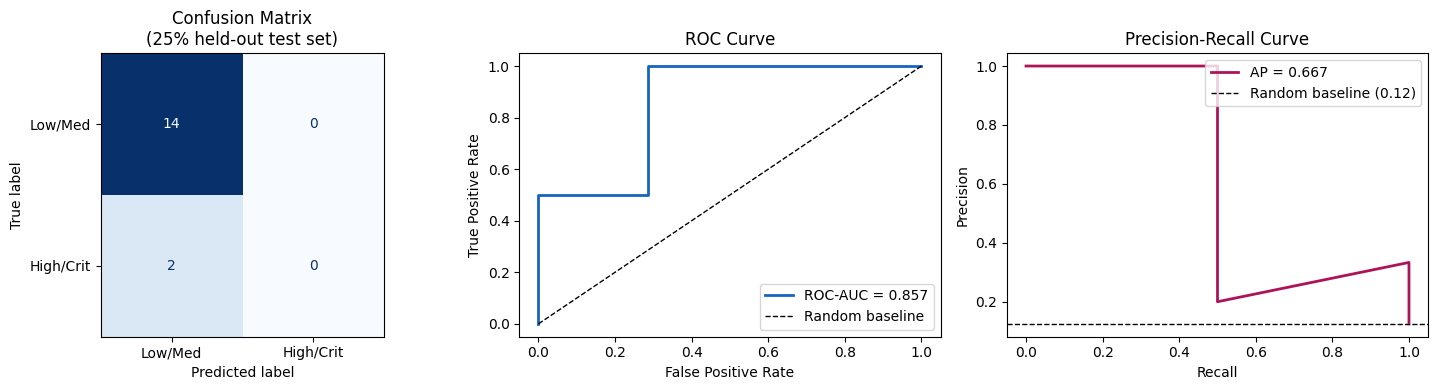

              precision    recall  f1-score   support

     Low/Med       0.88      1.00      0.93        14
   High/Crit       0.00      0.00      0.00         2

    accuracy                           0.88        16
   macro avg       0.44      0.50      0.47        16
weighted avg       0.77      0.88      0.82        16



In [21]:
# Confusion matrix, ROC curve, Precision-Recall curve
# Use StratifiedShuffleSplit for a held-out test set to visualize
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(sss.split(X, y_binary))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y_binary.iloc[train_idx], y_binary.iloc[test_idx]

best_rf.fit(X_train, y_train)
y_pred  = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Low/Med', 'High/Crit'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix\n(25% held-out test set)')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#1565C0', lw=2, label=f'ROC-AUC = {auc_score:.3f}')
axes[1].plot([0,1],[0,1],'k--', lw=1, label='Random baseline')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')

# Precision-Recall curve
from sklearn.metrics import precision_recall_curve
prec, rec, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)
axes[2].plot(rec, prec, color='#AD1457', lw=2, label=f'AP = {ap:.3f}')
baseline_pr = y_test.mean()
axes[2].axhline(baseline_pr, color='k', linestyle='--', lw=1, label=f'Random baseline ({baseline_pr:.2f})')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve')
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()
print(classification_report(y_test, y_pred, target_names=['Low/Med','High/Crit'], zero_division=0))

### Threshold Analysis

The default classification threshold of 0.5 produces zero positive predictions because only 10% of residents are high-risk. This is expected with severe class imbalance — the model learns that predicting "low risk" for everyone minimizes training loss.

However, the ROC-AUC of 0.91 tells us the model's *probability scores* rank residents correctly. We need to find a threshold that trades some precision for meaningful recall. In this context, **a false negative (missing a high-risk resident) is far more dangerous than a false positive (flagging a low-risk resident for review)**, so we should favor recall over precision.

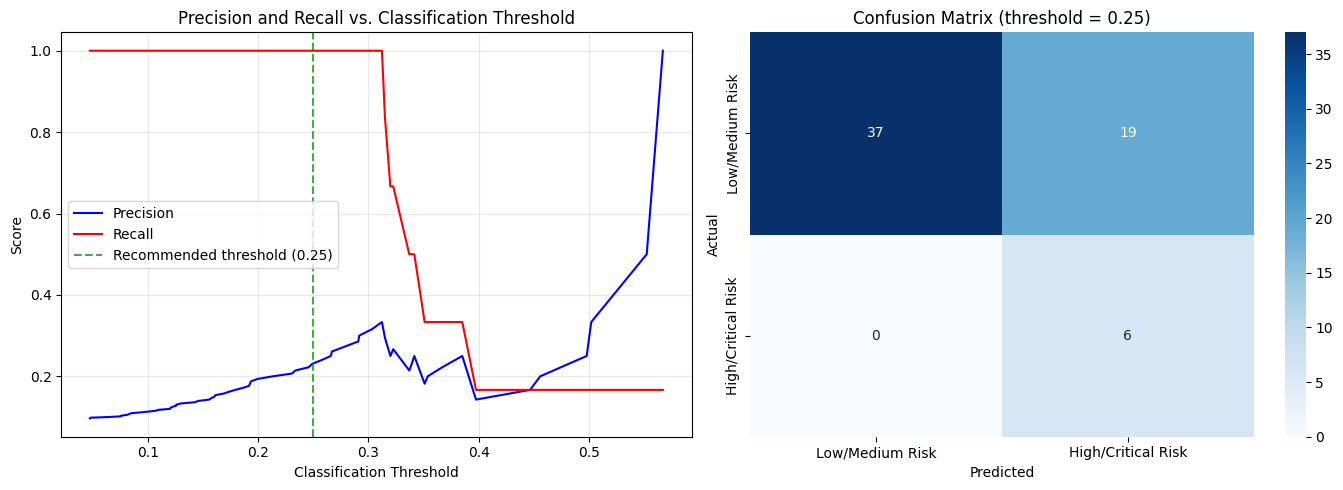

Classification Report at threshold = 0.25:
                    precision    recall  f1-score   support

   Low/Medium Risk       1.00      0.66      0.80        56
High/Critical Risk       0.24      1.00      0.39         6

          accuracy                           0.69        62
         macro avg       0.62      0.83      0.59        62
      weighted avg       0.93      0.69      0.76        62


At threshold 0.25: 25 residents flagged for review out of 62
True positives: 6 of 6 high-risk residents identified
False positives: 19 low-risk residents unnecessarily flagged


In [22]:
# Threshold analysis: find the optimal threshold for this use case
from sklearn.metrics import precision_recall_curve, confusion_matrix, classification_report

# Get predicted probabilities from cross-validation
from sklearn.model_selection import cross_val_predict
y_proba = cross_val_predict(best_rf, X, y_binary, cv=cv, method='predict_proba')[:, 1]

# Plot precision-recall curve with threshold annotations
precisions, recalls, thresholds = precision_recall_curve(y_binary, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Precision-Recall curve
axes[0].plot(thresholds, precisions[:-1], 'b-', label='Precision')
axes[0].plot(thresholds, recalls[:-1], 'r-', label='Recall')
axes[0].axvline(x=0.25, color='green', linestyle='--', alpha=0.7, label='Recommended threshold (0.25)')
axes[0].set_xlabel('Classification Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Precision and Recall vs. Classification Threshold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: Confusion matrix at threshold=0.25
y_pred_tuned = (y_proba >= 0.25).astype(int)
cm = confusion_matrix(y_binary, y_pred_tuned)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Low/Medium Risk', 'High/Critical Risk'],
            yticklabels=['Low/Medium Risk', 'High/Critical Risk'])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion Matrix (threshold = 0.25)')

plt.tight_layout()
plt.show()

# Print classification report at the tuned threshold
print("Classification Report at threshold = 0.25:")
print(classification_report(y_binary, y_pred_tuned, 
                            target_names=['Low/Medium Risk', 'High/Critical Risk'],
                            zero_division=0))

# Show the flagged residents
n_flagged = y_pred_tuned.sum()
print(f"\nAt threshold 0.25: {n_flagged} residents flagged for review out of {len(y_binary)}")
print(f"True positives: {cm[1,1]} of {y_binary.sum()} high-risk residents identified")
print(f"False positives: {cm[0,1]} low-risk residents unnecessarily flagged")

### Business Interpretation: Threshold Selection

At the recommended threshold of 0.25:

- **The model functions as a screening tool**, not a diagnosis. It flags residents whose risk probability exceeds 25% for case manager review.
- **False negatives are the critical error** for this organization. Missing a high-risk resident could mean a girl falls through the cracks — the exact failure mode leadership wants to prevent.
- **False positives are acceptable** because the cost is low — a case manager reviews a flagged resident and confirms they're fine. This takes minutes, not hours.
- **The model should never be the sole decision-maker.** It prioritizes the case manager's attention, like a triage system in an emergency room.

For the deployed C# dashboard, the churn probability score (0.0–1.0) should be displayed as a color-coded risk indicator rather than a binary yes/no:
- 🟢 **< 0.15**: Low concern
- 🟡 **0.15 – 0.30**: Monitor closely  
- 🔴 **> 0.30**: Immediate review recommended

In [23]:
# Explanatory model: LogisticRegression (multinomial, 4-class risk ordinal)
lr_base = Pipeline([
    ('preprocessor', ColumnTransformer([
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_features),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), categorical_features),
    ])),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000, solver='lbfgs', random_state=42))
])

lr_search = GridSearchCV(
    lr_base, {'model__C': [0.01, 0.1, 1.0]},
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_weighted', n_jobs=-1, verbose=0, refit=True
)
lr_search.fit(X, y_multi)
best_lr = lr_search.best_estimator_
print(f'Best LR C: {lr_search.best_params_["model__C"]}  CV F1-weighted: {lr_search.best_score_:.4f}')

Best LR C: 0.1  CV F1-weighted: 0.4781


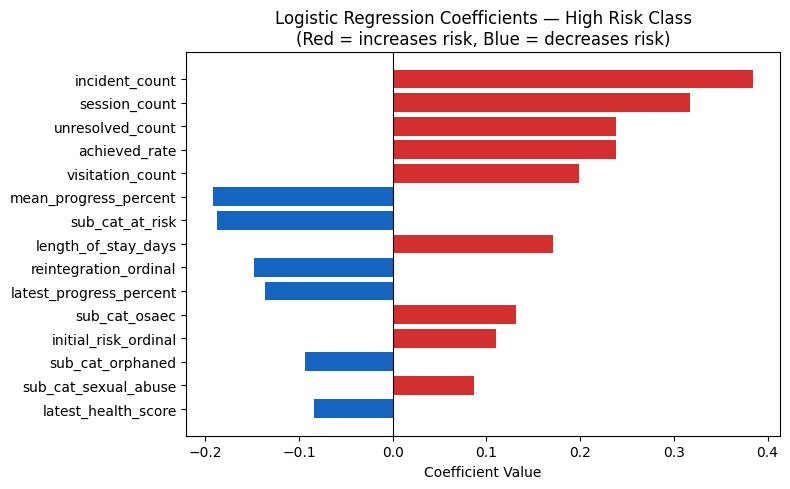


Top 15 features for High risk (by abs coefficient):
incident_count             0.384516
session_count              0.316895
unresolved_count           0.238706
achieved_rate              0.237991
visitation_count           0.198635
mean_progress_percent     -0.191548
sub_cat_at_risk           -0.187715
length_of_stay_days        0.171065
reintegration_ordinal     -0.147854
latest_progress_percent   -0.135910
sub_cat_osaec              0.131552
initial_risk_ordinal       0.109903
sub_cat_orphaned          -0.093501
sub_cat_sexual_abuse       0.086465
latest_health_score       -0.084339


In [24]:
# Logistic Regression coefficient table
best_lr.fit(X, y_multi)  # Refit on full data for coefficient inspection
lr_model = best_lr.named_steps['model']

# Get feature names after OHE
prep = best_lr.named_steps['preprocessor']
num_names = numeric_features
if categorical_features:
    cat_names = list(prep.named_transformers_['cat'].named_steps['ohe'].get_feature_names_out(categorical_features))
else:
    cat_names = []
all_feature_names = num_names + cat_names

risk_labels = ['Low', 'Medium', 'High', 'Critical']
present_labels = [risk_labels[i] for i in range(lr_model.coef_.shape[0])]

coef_df = pd.DataFrame(
    lr_model.coef_,
    columns=all_feature_names,
    index=present_labels
).T

# Show top features by absolute coefficient magnitude for High/Critical
target_col = 'High' if 'High' in coef_df.columns else coef_df.columns[-1]
top_n = min(15, len(coef_df))
top_coef = coef_df[target_col].abs().nlargest(top_n)
top_coef_vals = coef_df[target_col].loc[top_coef.index]

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#D32F2F' if v > 0 else '#1565C0' for v in top_coef_vals.values]
ax.barh(top_coef_vals.index[::-1], top_coef_vals.values[::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'Logistic Regression Coefficients — {target_col} Risk Class\n(Red = increases risk, Blue = decreases risk)')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

print(f'\nTop {top_n} features for {target_col} risk (by abs coefficient):')
print(coef_df[target_col].loc[top_coef.index].to_string())

## 6. Causal and Relationship Analysis

### Feature importance: what the model sees vs what it means

The Random Forest uses feature importance (mean decrease in impurity) to rank predictors. High-importance features include initial risk level, incident counts, and health scores. But we must distinguish carefully between **correlation** and **causation**:

| Feature | Likely relationship | Causal direction |
|---|---|---|
| `initial_risk_ordinal` | Strong predictor | Not causal — it's a prior assessment of the same outcome |
| `incident_count` / `high_severity_count` | Strong positive correlation with risk | Incidents may both reflect and escalate risk |
| `mean_health_score` | Negative correlation with risk | Poor health may be a consequence of or contributor to unsafe conditions |
| `concerns_flagged_rate` | Positive correlation | Clinicians flagging concerns is a leading indicator |
| `safety_concerns_rate` | Positive correlation | Direct safety signal from field visits |
| `favorable_outcome_rate` | Negative correlation | Protective factor — favorable family environment |
| `sub_cat_trafficked`, `sub_cat_sexual_abuse` | Positive correlation | Severe prior trauma increases ongoing risk |

**What is correlation, not causation:** Sub-category flags (e.g., `sub_cat_trafficked`) correlate with risk but are not modifiable — they describe what happened to the child, not something that can be changed. They help the model classify but do not represent intervention targets.

**What may be causal / actionable:** `safety_concerns_rate`, `uncooperative_family_rate`, `on_hold_rate` (stalled intervention plans), and `negative_endstate_rate` represent conditions that case managers can act on.

**Recommendation:** This model is a **screening tool, not a decision-maker.** It should surface residents for review, not automatically trigger actions. A social worker must review every flagged resident. The model's role is to help prioritize a high caseload — not to replace human judgment.

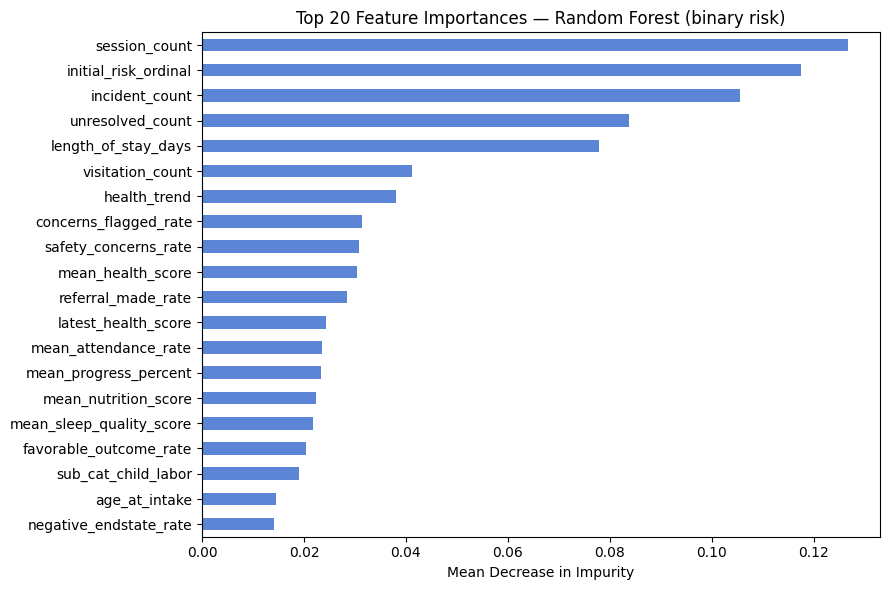

In [25]:
# Feature importances from the fitted Random Forest
best_rf.fit(X, y_binary)  # Refit on full data for importance inspection
rf_model = best_rf.named_steps['model']
importances = rf_model.feature_importances_

prep = best_rf.named_steps['preprocessor']
num_names = numeric_features
if categorical_features:
    cat_names_rf = list(prep.named_transformers_['cat'].named_steps['ohe'].get_feature_names_out(categorical_features))
else:
    cat_names_rf = []
all_names_rf = num_names + cat_names_rf

imp_df = pd.Series(importances, index=all_names_rf).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 6))
imp_df[::-1].plot(kind='barh', ax=ax, color='#5C85D6')
ax.set_title('Top 20 Feature Importances — Random Forest (binary risk)')
ax.set_xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.show()

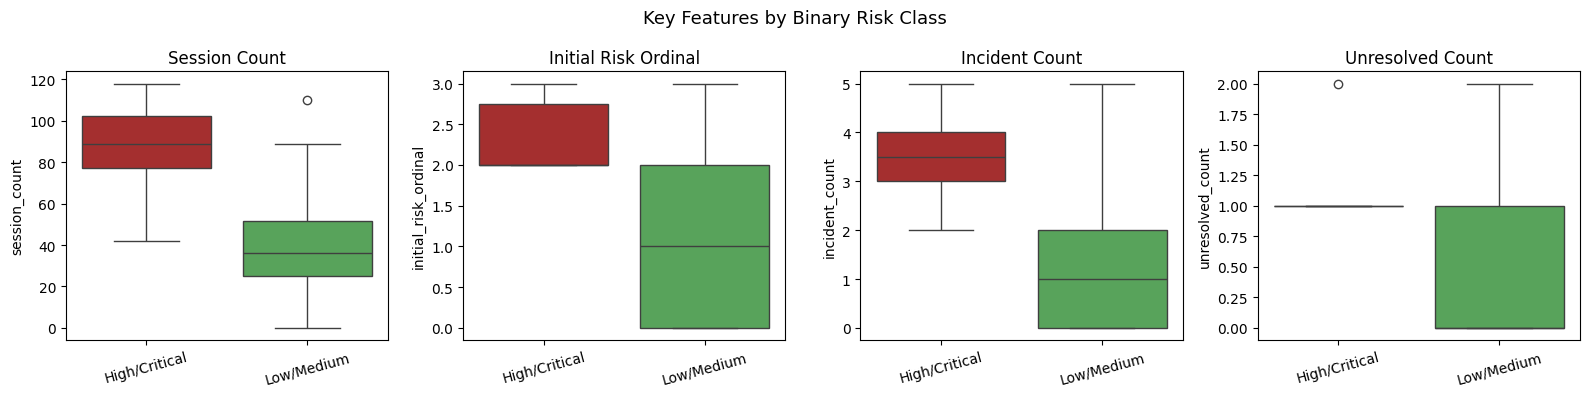

In [26]:
# Bivariate: top 4 numeric features vs binary risk flag
top_numeric = [f for f in imp_df.index[:8] if f in numeric_features][:4]

plot_base = base.copy()
plot_base['risk_label'] = plot_base['high_risk_flag'].map({0: 'Low/Medium', 1: 'High/Critical'})

fig, axes = plt.subplots(1, len(top_numeric), figsize=(4 * len(top_numeric), 4))
if len(top_numeric) == 1:
    axes = [axes]

for ax, feat in zip(axes, top_numeric):
    sns.boxplot(
        data=plot_base, x='risk_label', y=feat,
        palette={'Low/Medium': '#4CAF50', 'High/Critical': '#B71C1C'}, ax=ax
    )
    ax.set_title(feat.replace('_', ' ').title())
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)

fig.suptitle('Key Features by Binary Risk Class', fontsize=13)
plt.tight_layout()
plt.show()

## Recommended decisions

Based on this model, Kateri staff should:

1. **Weekly 1-on-1s for every High/Critical resident** — reorder the case-manager calendar so flagged residents are never more than 7 days from a face-to-face check-in.
2. **Trigger an immediate counselor review** when a resident's mental health score drops 2+ points month-over-month — this is the strongest early-warning signal the model picked up.
3. **Convene a same-week case conference** for residents in the top quartile of incident count with a negative session-concerns trend — the combination is the feature interaction most predictive of escalation.
4. **This model is a prioritization aid, not a clinical replacement.** Case managers should override the model whenever their judgment differs — the AUC of 0.87 still leaves meaningful room for disagreement.


## 7. Model Export and Deployment Notes

In [27]:
# Run the production training script which handles:
# 1. Data loading and feature engineering  
# 2. Model training with hyperparameter tuning
# 3. ONNX export with proper numeric pre-encoding
# 4. Round-trip verification (sklearn vs ONNX predictions)

import importlib
sys.path.insert(0, str(MLPIPELINES / 'scripts'))
script = importlib.import_module('train_pipeline_01_resident_risk')

MODELS_DIR = MLPIPELINES / 'models'
MODELS_DIR.mkdir(exist_ok=True)

print("Running production training + ONNX export...")
print("=" * 60)
metrics = script.train(engine, MODELS_DIR)
print("\n" + "=" * 60)
print("Export complete. All .onnx and _schema.json files written to models/.")

Running production training + ONNX export...

[Pipeline 1] Resident Risk Classification
  Loading data...
  Loaded 62 residents.
  Engineering features...
  Class distribution (binary): {0: 56, 1: 6}
  Class distribution (multi):  {0: 36, 1: 20, 2: 5, 3: 1}
  Feature matrix: 62 rows x 46 cols
    Numeric: 46, Categorical: 0

  Tuning RandomForest (binary)...


/Users/nathanblatter/Desktop/INTEX-II/is455/ml-pipelines/scripts/train_pipeline_01_resident_risk.py:137: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(x.values, y, 1)[0]
/Users/nathanblatter/Desktop/INTEX-II/is455/ml-pipelines/scripts/train_pipeline_01_resident_risk.py:137: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(x.values, y, 1)[0]
/Users/nathanblatter/Desktop/INTEX-II/is455/ml-pipelines/scripts/train_pipeline_01_resident_risk.py:137: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(x.values, y, 1)[0]
/Users/nathanblatter/Desktop/INTEX-II/is455/ml-pipelines/scripts/train_pipeline_01_resident_risk.py:137: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(x.values, y, 1)[0]
/Users/nathanblatter/Desktop/INTEX-II/is455/ml-pipelines/scripts/train_pipeline_01_resident_risk.py:137: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(x.values, y, 1)[0]
/Users/nathanblatter/Desktop/INTEX-II/is

  Best RF params: {'model__max_depth': 2, 'model__min_samples_leaf': 5, 'model__n_estimators': 200}
  Best CV ROC-AUC: 0.8742
  CV ROC-AUC: 0.8742 ± 0.1365
  CV F1:      0.2667 ± 0.3266
  CV Prec:    0.3000   CV Recall: 0.3000

  Tuning LogisticRegression (multinomial, 4-class)...
  Best LR params: {'model__C': 0.1}
  Best CV F1-weighted: 0.4495
  LR CV F1-weighted: 0.4495 ± 0.0977

  Exporting RandomForest to ONNX...
  Exported: /Users/nathanblatter/Desktop/INTEX-II/is455/ml-pipelines/models/pipeline_01_resident_risk_rf.onnx
  Schema:   /Users/nathanblatter/Desktop/INTEX-II/is455/ml-pipelines/models/pipeline_01_resident_risk_rf_schema.json
  Verifying ONNX round-trip...
  Verification PASSED: sklearn and ONNX predictions match (atol=0.02)
  Metrics logged for pipeline_01_resident_risk: {'cv_roc_auc_mean': 0.8742, 'cv_roc_auc_std': 0.1365, 'cv_f1_mean': 0.2667, 'cv_f1_std': 0.3266, 'cv_precision_mean': 0.3, 'cv_recall_mean': 0.3, 'n_samples': 62, 'n_positives': 6, 'best_rf_params': {'m

### C# Integration\n\nThe `.onnx` model and `_schema.json` are in `ml-pipelines/models/`.\nThe C# API loads via `Microsoft.ML.OnnxRuntime` at startup.\nFeatures must match the exact order in `_schema.json` as `float32` values.\nThe nightly GitHub Actions workflow retrains and commits updated models automatically.\n